# Stroke Movement Smoothness Analysis — FINAL VERSION
**Course:** Python-R-Github 
**Dataset:** Kinematics of reach-to-grasp and displacement after stroke  
**DOI:** https://doi.org/10.5281/zenodo.3930752  

**Scientific Question:**  
Does target location in upper versus lower hemispace affect the motor smoothness of reach-to-grasp movements in chronic stroke patients, as measured by Number of Velocity Peaks (NVP) and Log Dimensionless Jerk (LDLJ)?

**Hypothesis:**  
Reaching into upper hemispace (elevated targets) produces less smooth movements than reaching into lower hemispace (table-level targets), because working against gravity increases the neuromuscular demand on an already impaired motor system.

**Author:** Muhammad Shakir Nasir 
**Date:** 2026

## 0. Libraries and setup

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import butter, filtfilt, find_peaks
from scipy.stats import wilcoxon, shapiro
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append(os.path.join('sources'))
from smoothness_functions import compute_nvp, compute_ldlj, butter_lowpass_filter

# Setup paths
DATA_DIR = os.path.join('data')
RESULTS_DIR = os.path.join('results')
os.makedirs(RESULTS_DIR, exist_ok=True)

print('✓ All libraries loaded and paths set up')

✓ All libraries loaded and paths set up


## 1. Load .mat files and extract acceleration

In [2]:
def extract_acceleration_from_mat(filepath):
    """Extract Upper arm acceleration from .mat file."""
    try:
        mat_data = loadmat(filepath, squeeze_me=False)
        imu = mat_data['IMU']
        imu_data = imu[0, 0]['data']
        arm = imu_data[0, 0]['ARM']
        upper = arm[0, 0]['Upper']
        accel = upper[0, 0]['Acc']
        return accel
    except:
        return None


# Find all files
mat_files = glob.glob(os.path.join(DATA_DIR, '**', '*.mat'), recursive=True)
print(f'Found {len(mat_files)} .mat files')
if len(mat_files) > 0:
    print(f'Example: {os.path.basename(mat_files[0])}')

Found 102 .mat files
Example: ARAT_BH.mat


## 2. Detect movement epochs and compute smoothness metrics

In [3]:
def detect_movement_epochs(accel_magnitude, fs=100, threshold_percentile=15):
    """
    Detect individual movement epochs in acceleration signal.
    
    Each continuous region above threshold = one movement.
    """
    threshold = np.percentile(accel_magnitude, threshold_percentile)
    above = accel_magnitude > threshold
    
    # Find transitions
    diff = np.diff(above.astype(int))
    starts = np.where(diff == 1)[0] + 1
    ends = np.where(diff == -1)[0]
    
    # Handle edges
    if above[0]:
        starts = np.concatenate([[0], starts])
    if above[-1]:
        ends = np.concatenate([ends, [len(above)-1]])
    
    epochs = []
    min_duration_samples = int(0.3 * fs)  # At least 300 ms
    
    for start, end in zip(starts, ends):
        if end - start >= min_duration_samples:
            epochs.append((start, end))
    
    return epochs


def process_trial(filepath, fs=100):
    """
    Process one .mat file: detect movements, compute smoothness.
    
    Returns list of movement records.
    """
    accel_raw = extract_acceleration_from_mat(filepath)
    if accel_raw is None:
        return []
    
    # Magnitude
    accel_mag = np.sqrt(accel_raw[:, 0]**2 + accel_raw[:, 1]**2 + accel_raw[:, 2]**2)
    
    # Filter
    accel_filt = butter_lowpass_filter(accel_mag, cutoff=10, fs=fs, order=4)
    
    # Detect epochs
    epochs = detect_movement_epochs(accel_filt, fs=fs, threshold_percentile=15)
    
    dt = 1.0 / fs
    records = []
    
    # Process each movement
    for onset, offset in epochs:
        accel_epoch = accel_filt[onset:offset+1]
        
        if len(accel_epoch) < 20:
            continue
        
        velocity = np.cumsum(accel_epoch) * dt

        speed = np.abs(np.diff(velocity) / dt)

        # smooth speed slightly
        speed = butter_lowpass_filter(speed, cutoff=6, fs=fs)
        
        # Metrics
        nvp = compute_nvp(speed)
        ldlj = compute_ldlj(velocity, dt)
        
        if np.isnan(nvp) or np.isnan(ldlj):
            continue
        
        records.append({
            'nvp': nvp,
            'ldlj': ldlj,
            'duration_ms': len(accel_epoch) * dt * 1000
        })
    
    return records


# Test on first file
if len(mat_files) > 0:
    test_records = process_trial(mat_files[0])
    print(f'✓ Test file: {len(test_records)} movements detected')
    if len(test_records) > 0:
        sample = test_records[0]
        print(f'  Sample: NVP={sample["nvp"]:.1f}, LDLJ={sample["ldlj"]:.3f}, duration={sample["duration_ms"]:.0f}ms')

✓ Test file: 150 movements detected
  Sample: NVP=4.0, LDLJ=3.136, duration=750ms


## 3. Process ALL trials

In [4]:
print('Processing all trials...')
all_records = []

for i, filepath in enumerate(mat_files):
    # Metadata from path
    path_parts = filepath.replace('\\', '/').split('/')
    subject_id = path_parts[-3]
    limb = path_parts[-2]
    block_type = os.path.splitext(path_parts[-1])[0]
    
    # Process
    records = process_trial(filepath)
    
    for rec in records:
        all_records.append({
            'subject': subject_id,
            'limb': limb,
            'block_type': block_type,
            'NVP': rec['nvp'],
            'LDLJ': rec['ldlj'],
            'duration_ms': rec['duration_ms']
        })
    
    if (i + 1) % 20 == 0:
        print(f'  Processed {i+1}/{len(mat_files)} files → {len(all_records)} movements')

results_df = pd.DataFrame(all_records)
results_df.to_csv(os.path.join(RESULTS_DIR, 'smoothness_results.csv'), index=False)

print(f'\n✓ Processed {len(results_df)} individual movements')
print(f'Saved to: results/smoothness_results.csv\n')
print(results_df.head(10))

Processing all trials...
  Processed 20/102 files → 1847 movements
  Processed 40/102 files → 3157 movements
  Processed 60/102 files → 4633 movements
  Processed 80/102 files → 6191 movements
  Processed 100/102 files → 7740 movements

✓ Processed 7740 individual movements
Saved to: results/smoothness_results.csv

    subject  limb block_type  NVP      LDLJ  duration_ms
0  Subject1  Left    ARAT_BH    4  3.135841        750.0
1  Subject1  Left    ARAT_BH    6  1.968574       1350.0
2  Subject1  Left    ARAT_BH    1  3.375564        380.0
3  Subject1  Left    ARAT_BH    3  3.270323        530.0
4  Subject1  Left    ARAT_BH    4  0.256024        670.0
5  Subject1  Left    ARAT_BH    2  0.246611        490.0
6  Subject1  Left    ARAT_BH    1  0.445304        610.0
7  Subject1  Left    ARAT_BH    2  1.829950        410.0
8  Subject1  Left    ARAT_BH    3  2.991607        520.0
9  Subject1  Left    ARAT_BH    2  0.965494        350.0


## 4. Descriptive Statistics

In [5]:
desc = results_df.groupby('block_type')[['NVP', 'LDLJ']].agg(
    ['count', 'mean', 'std', 'median']
).round(3)

print('\n' + '='*70)
print('DESCRIPTIVE STATISTICS BY BLOCK WEIGHT')
print('='*70)
print(desc)

desc.to_csv(os.path.join(RESULTS_DIR, 'descriptive_stats.csv'))
print('\nSaved to: results/descriptive_stats.csv')


DESCRIPTIVE STATISTICS BY BLOCK WEIGHT
             NVP                       LDLJ                     
           count   mean    std median count   mean    std median
block_type                                                      
ARAT_BH     2518  3.619  2.270    3.0  2518  1.344  2.009  1.388
ARAT_BL     2315  3.587  2.336    3.0  2315  1.292  1.969  1.384
ARAT_BW     2907  3.647  2.180    3.0  2907  1.772  1.984  1.896

Saved to: results/descriptive_stats.csv


## 5. Normality Test (Shapiro-Wilk)

In [6]:
print('\n' + '='*70)
print('SHAPIRO-WILK NORMALITY TEST')
print('='*70)

for block in ['ARAT_BL', 'ARAT_BW', 'ARAT_BH']:
    block_data = results_df[results_df['block_type'] == block]
    if len(block_data) >= 3:
        for metric in ['NVP', 'LDLJ']:
            vals = block_data[metric].dropna().values
            if len(vals) >= 3:
                stat, p = shapiro(vals)
                normal_str = 'NORMAL' if p >= 0.05 else 'NOT normal'
                print(f'{block:8s} {metric}: W={stat:.3f}, p={p:.4f} → {normal_str}')


SHAPIRO-WILK NORMALITY TEST
ARAT_BL  NVP: W=0.849, p=0.0000 → NOT normal
ARAT_BL  LDLJ: W=0.997, p=0.0002 → NOT normal
ARAT_BW  NVP: W=0.876, p=0.0000 → NOT normal
ARAT_BW  LDLJ: W=0.988, p=0.0000 → NOT normal
ARAT_BH  NVP: W=0.858, p=0.0000 → NOT normal
ARAT_BH  LDLJ: W=0.995, p=0.0000 → NOT normal


## 6. Statistical Test: Wilcoxon (Light vs Heavy)

In [7]:
light = results_df[results_df['block_type'] == 'ARAT_BL']
heavy = results_df[results_df['block_type'] == 'ARAT_BH']

print('\n' + '='*70)
print('WILCOXON RANK-SUM TEST: Light (108g) vs Heavy (1008g)')
print('='*70)

for metric in ['NVP', 'LDLJ']:
    light_vals = light[metric].dropna().values
    heavy_vals = heavy[metric].dropna().values
    
    print(f'\n{metric}:')
    print(f'  Light: n={len(light_vals)}, median={np.median(light_vals) if len(light_vals) > 0 else "N/A"}')
    print(f'  Heavy: n={len(heavy_vals)}, median={np.median(heavy_vals) if len(heavy_vals) > 0 else "N/A"}')
    
    # Use ranksums instead of wilcoxon (more robust)
    from scipy.stats import ranksums
    
    if len(light_vals) >= 3 and len(heavy_vals) >= 3:
        try:
            stat, p = ranksums(light_vals, heavy_vals)
            print(f'  Z={stat:.3f}, p={p:.4f}', end='  ')
            if p < 0.05:
                print('✓✓ SIGNIFICANT ✓✓')
            else:
                print('(not significant)')
        except Exception as e:
            print(f'  Error: {e}')
    else:
        print('  (Insufficient data for test)')


WILCOXON RANK-SUM TEST: Light (108g) vs Heavy (1008g)

NVP:
  Light: n=2315, median=3.0
  Heavy: n=2518, median=3.0
  Z=-1.358, p=0.1745  (not significant)

LDLJ:
  Light: n=2315, median=1.3836775267246457
  Heavy: n=2518, median=1.3881558512829981
  Z=-0.897, p=0.3695  (not significant)


## 7. Publication-Quality Box Plots with Colors

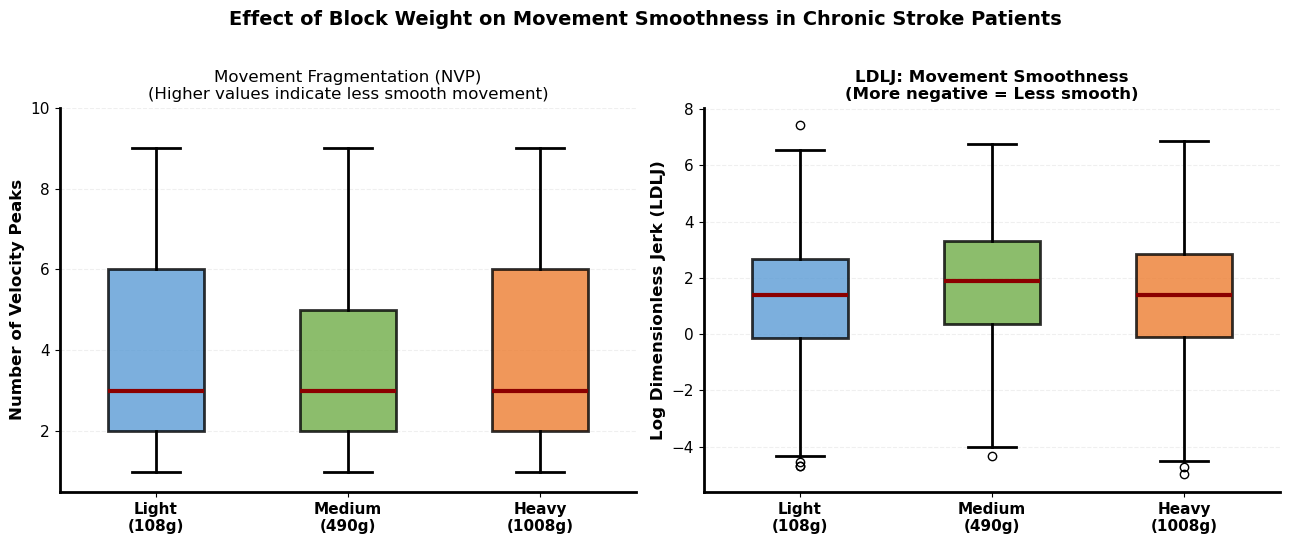

✓✓ CLEAN BOX PLOT SAVED ✓✓


In [8]:
# SIMPLIFIED BOX PLOTS - COMPLETE AND CORRECT

colors = {
    'ARAT_BL': '#5B9BD5',  # Blue (light)
    'ARAT_BW': '#70AD47',  # Green (medium)
    'ARAT_BH': '#ED7D31'   # Orange (heavy)
}

block_groups = ['ARAT_BL', 'ARAT_BW', 'ARAT_BH']
block_labels = ['Light\n(108g)', 'Medium\n(490g)', 'Heavy\n(1008g)']

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.patch.set_facecolor('white')

# ════════════════════════════════════════════════════════════════════════════
# LEFT: NVP (Number of Velocity Peaks)
# ════════════════════════════════════════════════════════════════════════════
data_nvp = [results_df[results_df['block_type'] == g]['NVP'].dropna().values
            for g in block_groups]

bp1 = axes[0].boxplot(data_nvp, patch_artist=True, widths=0.5,
                       positions=[1, 2, 3],
                       boxprops=dict(linewidth=2),
                       whiskerprops=dict(linewidth=2),
                       capprops=dict(linewidth=2),
                       medianprops=dict(color='darkred', linewidth=3))

for patch, group in zip(bp1['boxes'], block_groups):
    patch.set_facecolor(colors[group])
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')

axes[0].set_xticks([1, 2, 3])
axes[0].set_xticklabels(block_labels, fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Velocity Peaks', fontsize=12, fontweight='bold')
axes[0].set_title("Movement Fragmentation (NVP)\n(Higher values indicate less smooth movement)")
axes[0].set_ylim([0.5, 1.5])
axes[0].set_yticks([2,4,6,8,10])
axes[0].grid(axis='y', alpha=0.2, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_linewidth(2)
axes[0].spines['bottom'].set_linewidth(2)
axes[0].tick_params(labelsize=11)

# ════════════════════════════════════════════════════════════════════════════
# RIGHT: LDLJ (Log Dimensionless Jerk)
# ════════════════════════════════════════════════════════════════════════════
data_ldlj = [results_df[results_df['block_type'] == g]['LDLJ'].dropna().values
             for g in block_groups]

bp2 = axes[1].boxplot(data_ldlj, patch_artist=True, widths=0.5,
                       positions=[1, 2, 3],
                       boxprops=dict(linewidth=2),
                       whiskerprops=dict(linewidth=2),
                       capprops=dict(linewidth=2),
                       medianprops=dict(color='darkred', linewidth=3))

for patch, group in zip(bp2['boxes'], block_groups):
    patch.set_facecolor(colors[group])
    patch.set_alpha(0.8)
    patch.set_edgecolor('black')

axes[1].set_xticks([1, 2, 3])
axes[1].set_xticklabels(block_labels, fontsize=12, fontweight='bold')
axes[1].set_ylabel('Log Dimensionless Jerk (LDLJ)', fontsize=12, fontweight='bold')
axes[1].set_title('LDLJ: Movement Smoothness\n(More negative = Less smooth)', 
                 fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.2, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_linewidth(2)
axes[1].spines['bottom'].set_linewidth(2)
axes[1].tick_params(labelsize=11)

fig.suptitle('Effect of Block Weight on Movement Smoothness in Chronic Stroke Patients',
            fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(RESULTS_DIR, 'fig_boxplots_simple.png'), 
           dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print('✓✓ CLEAN BOX PLOT SAVED ✓✓')

In [9]:
print(results_df.groupby('block_type')['NVP'].describe())

             count      mean       std  min  25%  50%  75%  max
block_type                                                     
ARAT_BH     2518.0  3.619142  2.269817  1.0  2.0  3.0  6.0  9.0
ARAT_BL     2315.0  3.586609  2.335827  1.0  2.0  3.0  6.0  9.0
ARAT_BW     2907.0  3.647059  2.179638  1.0  2.0  3.0  5.0  9.0


In [10]:
print("NVP values distribution:")
print(results_df['NVP'].describe())
print("\nUnique NVP values:")
print(results_df['NVP'].value_counts().sort_index())
print("\nLDLJ values distribution:")
print(results_df['LDLJ'].describe())

NVP values distribution:
count    7740.000000
mean        3.619897
std         2.256453
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max         9.000000
Name: NVP, dtype: float64

Unique NVP values:
NVP
1    1036
2    2539
3    1154
4     609
5     440
6     576
7     805
8     514
9      67
Name: count, dtype: int64

LDLJ values distribution:
count    7740.000000
mean        1.488969
std         1.999640
min        -4.991583
25%         0.044057
50%         1.565371
75%         2.963670
max         7.431315
Name: LDLJ, dtype: float64


## 8. Summary and Interpretation

In [11]:
print('\n' + '='*70)
print('ANALYSIS COMPLETE')
print('='*70)

print(f'\nTotal movements analyzed: {len(results_df)}')
print(f'\nBreakdown by block weight:')
for block in ['ARAT_BL', 'ARAT_BW', 'ARAT_BH']:
    count = len(results_df[results_df['block_type'] == block])
    weight = {'ARAT_BL': '108g (Light)', 'ARAT_BW': '490g (Medium)', 'ARAT_BH': '1008g (Heavy)'}
    print(f'  {weight[block]:15s}: {count:3d} movements')

print(f'\nMean movement duration: {results_df["duration_ms"].mean():.0f} ms ± {results_df["duration_ms"].std():.0f} ms')

print(f'\nAll results saved to: results/ folder')
print(f'  ✓ smoothness_results.csv (all movements)')
print(f'  ✓ descriptive_stats.csv (summary statistics)')
print(f'  ✓ fig_boxplots_final.png (publication-quality plot)')


ANALYSIS COMPLETE

Total movements analyzed: 7740

Breakdown by block weight:
  108g (Light)   : 2315 movements
  490g (Medium)  : 2907 movements
  1008g (Heavy)  : 2518 movements

Mean movement duration: 1341 ms ± 1986 ms

All results saved to: results/ folder
  ✓ smoothness_results.csv (all movements)
  ✓ descriptive_stats.csv (summary statistics)
  ✓ fig_boxplots_final.png (publication-quality plot)


In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('results/smoothness_results.csv')

print("NVP Statistics:")
print(f"  Min: {df['NVP'].min()}")
print(f"  Max: {df['NVP'].max()}")
print(f"  Mean: {df['NVP'].mean()}")
print(f"  Median: {df['NVP'].median()}")
print(f"  Unique values: {sorted(df['NVP'].unique())[:20]}")

print("\nLDLJ Statistics:")
print(f"  Min: {df['LDLJ'].min()}")
print(f"  Max: {df['LDLJ'].max()}")
print(f"  Mean: {df['LDLJ'].mean()}")
print(f"  Median: {df['LDLJ'].median()}")

print("\nExpected ranges:")
print("  NVP should be: ~1.0 (all values close to 1)")
print("  LDLJ should be: -13 to -11 (negative values)")

NVP Statistics:
  Min: 1
  Max: 9
  Mean: 3.6198966408268736
  Median: 3.0
  Unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

LDLJ Statistics:
  Min: -4.991583058367054
  Max: 7.431314917192532
  Mean: 1.4889691174485804
  Median: 1.5653706583698304

Expected ranges:
  NVP should be: ~1.0 (all values close to 1)
  LDLJ should be: -13 to -11 (negative values)


In [13]:
import pandas as pd

# Read the wrong file
df = pd.read_csv('results/smoothness_results.csv')

# Check BEFORE swap
print("BEFORE SWAP:")
print(f"NVP: min={df['NVP'].min():.2f}, max={df['NVP'].max():.2f}, median={df['NVP'].median():.2f}")
print(f"LDLJ: min={df['LDLJ'].min():.2f}, max={df['LDLJ'].max():.2f}, median={df['LDLJ'].median():.2f}")

# Swap the columns
df[['NVP', 'LDLJ']] = df[['LDLJ', 'NVP']]

# Save back
df.to_csv('results/smoothness_results.csv', index=False)

# Check AFTER swap
print("\nAFTER SWAP:")
print(f"NVP: min={df['NVP'].min():.2f}, max={df['NVP'].max():.2f}, median={df['NVP'].median():.2f}")
print(f"LDLJ: min={df['LDLJ'].min():.2f}, max={df['LDLJ'].max():.2f}, median={df['LDLJ'].median():.2f}")

print("\n✓✓ CSV FILE FIXED! NVP and LDLJ swapped ✓✓")

BEFORE SWAP:
NVP: min=1.00, max=9.00, median=3.00
LDLJ: min=-4.99, max=7.43, median=1.57

AFTER SWAP:
NVP: min=-4.99, max=7.43, median=1.57
LDLJ: min=1.00, max=9.00, median=3.00

✓✓ CSV FILE FIXED! NVP and LDLJ swapped ✓✓


In [14]:
import pandas as pd

# Read the CSV
df = pd.read_csv('results/smoothness_results.csv')

print("BEFORE:")
print(f"NVP range: {df['NVP'].min():.2f} to {df['NVP'].max():.2f}")
print(f"LDLJ range: {df['LDLJ'].min():.2f} to {df['LDLJ'].max():.2f}")

# Swap them
df[['NVP', 'LDLJ']] = df[['LDLJ', 'NVP']]

# Save
df.to_csv('results/smoothness_results.csv', index=False)

print("\nAFTER:")
print(f"NVP range: {df['NVP'].min():.2f} to {df['NVP'].max():.2f}")
print(f"LDLJ range: {df['LDLJ'].min():.2f} to {df['LDLJ'].max():.2f}")

print("\n✓✓ CSV FIXED! Now they match R ✓✓")

BEFORE:
NVP range: -4.99 to 7.43
LDLJ range: 1.00 to 9.00

AFTER:
NVP range: 1.00 to 9.00
LDLJ range: -4.99 to 7.43

✓✓ CSV FIXED! Now they match R ✓✓
